# Julián Serrano Chacón
# Mika Rodríguez Castro

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import sounddevice as sd
import time # para medir tiempos de ejecución

# graficos en el notebook
%matplotlib inline

SRATE = 48000 # Sample rate, para todo el notebook

#### Ejercicio 1

Modificar el reproductor con control de volumen visto en clase (con slider de IpyWidgets) para que permita ajustar el volumen de cada canal por separado, a través de dos variables volL y volR (volumen del canal izquierdo y derecho). Si la muestra de entrada es mono, debe lanzarse una excepción e interrumpir la ejecución. Dado un chunk de audio estéreo almacenado en un array de NumPy bloque, el canal izquierdo puede obtenerse con bloque[:,0] y el derecho con bloque[:,1]

In [4]:
import numpy as np         
import sounddevice as sd   
import soundfile as sf     
from ipywidgets import interact


CHUNK = 2048
data, SRATE = sf.read('media/ex1.wav',dtype=np.float32)

#! no se si hacer un try
if (len(data.shape)==1): raise Exception("Mono not supported")
print(f"SRATE: {SRATE}   Format: {data.dtype}   Channels: {len(data.shape)}    Len: {data.shape[0]}")

# * volumen Izquierdo y volumen derecho
volL = 0.5
volR = 0.5

# contador de frames, global
current_frame = 0
def callback(outdata, frames, time, status):
    global current_frame       # para actualizarlo en cada callBack
    if status: print(status)

    # ojo, este print es muy lento... puede provocar underruns
    #print(f"\rNum Bloque: {current_frame//CHUNK}  frame: {current_frame}", end='') 

    # escribimos los samples correspondientes en el outdata que viene dado
    bloque = data[current_frame : current_frame+CHUNK]

    # * En vez de modificar el volumen en todos los canales directamente usando la instruccion anterior,
    # * se modifica cada uno de los canales por separado usando sus respectivos volumenes
    bloque[:,0] *= volL
    bloque[:,1] *= volR
        
    chunksize = bloque.shape[0]

    outdata[:chunksize] = bloque       
    
    if chunksize < frames: # ha terminado?
        print('fin')
        outdata[chunksize:] = 0 # rellenamos con 0's el resto de outdata
        raise sd.CallbackStop()

    # actualizamos frame con los frames procesados    
    current_frame += chunksize


# stream de salida con callBack
stream = sd.OutputStream(samplerate=SRATE, channels=len(data.shape),
    callback=callback, blocksize=CHUNK)
stream.start()


# controles de reproducción: volumen y parada

# * Hacemos un slider para volumen izquierdo y derecho

def LvolCtrl(Lv):
    global volL
    volL = Lv 
interact(LvolCtrl, Lv=(0.0,1.0,0.01))

def RvolCtrl(Rv):
    global volR
    volR = Rv  
interact(RvolCtrl, Rv=(0.0,1.0,0.01))


def pauseCtrl(pause):
    if pause==True:
        stream.stop()        
    else:
        stream.start()   
# lo interpreta como un checkbox
interact(pauseCtrl, pause=False)       



def stopCtrl(stop):
    if stop==True:
        stream.stop()
        stream.close()
interact(stopCtrl, stop=False)        


SRATE: 44100   Format: float32   Channels: 2    Len: 4109807


interactive(children=(FloatSlider(value=0.5, description='Lv', max=1.0, step=0.01), Output()), _dom_classes=('…

interactive(children=(FloatSlider(value=0.5, description='Rv', max=1.0, step=0.01), Output()), _dom_classes=('…

interactive(children=(Checkbox(value=False, description='pause'), Output()), _dom_classes=('widget-interact',)…

interactive(children=(Checkbox(value=False, description='stop'), Output()), _dom_classes=('widget-interact',))

<function __main__.stopCtrl(stop)>

#### Ejercicio 2

Generar una muestra de ruido blanco de una duración dada en segundos. Para ello definiremos dos
funciones:

- noise1(dur): crea un array vacío con np.empty. El tamaño se calcula en función de dur
(1 segundo requiere SRATE muestras). A continuación rellena cada una de sus componentes
con valores aleatorios del intervalo [-1,1] utilizando la función básica random.random(), que
genera valores individuales.

- noise2(dur): genera directamente la señal en un array de tamaño adecuado utilizando la
función de NumPy random.random o random.uniform, que delegan la generación del array
completo directamente en NumPy.

Dibujar la señal obtenida con Matplotlib. Para ver samples aislados puede generarse una muestra
de corta duración o bien dibujar solo una parte de la señal (haciendo slicing de arrays). Asegurarse
de que los valores generados están en el intervalo [-1,1].
Comparar el tiempo de ejecución de ambos métodos generando señales de suficiente duración. Para
medir el tiempo de ejecución de un fragmento de código puede hacerse:

    start = time.time()
    # código ...
    print(f'time: {time.time() - start}')

¿Qué versión de noise es más eficiente?

Generar una señal de ruido de 1 segundo de duración y reproducirla.

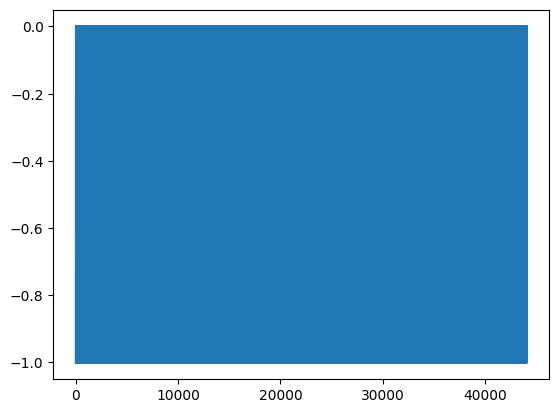

In [ ]:
import numpy as np         
import sounddevice as sd
import matplotlib.pyplot as plt
import random as rnd  

data

def noise1(dur):
    global data 
    data = np.empty([SRATE * dur])

    for i in range(0, SRATE * dur):
        data[i] = (rnd.random() * 2) - 1

def noise2(dur):
    global data
    data = np.random.uniform(-1.0, 1.0, SRATE * dur)

noise1(1)

plt.figure(1)
plt.plot(data)
plt.show()

sd.play(data, SRATE)
